# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

import pickle

In [2]:
import pandas as pd 
import numpy as np

In [3]:
from scipy.stats import norm, invgamma
# estimators
# from econml.grf import CausalForest
from statsmodels.regression.linear_model import OLS
from sklearn.linear_model import LinearRegression, Lasso

from scipy.integrate import quad 
from scipy.stats import ks_2samp

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [5]:
from core.variables import * 
from core.segment_targeting_estimators import *
from core.dgp import *
from core.segment_targeting_experiments import *

import core.continuous_segment as cs 

# DGP

$$
\begin{aligned}
Y_i & = \alpha'X_i T_i + \beta'X_i + \epsilon_i \\ 
\end{aligned}
$$

In [6]:
dgp_params = {
    'treatment_space': np.array([0, 1, 2, 3, 4]),
    'n_features': 2,
    'alpha_lb': 0.5, 'alpha_ub': 1.5,
    'beta_lb': 1, 'beta_ub': 3,
    'noise_std': 2, 'seed': 0
}

dgp = ContinuousSegments(**dgp_params)

In [7]:
char_arr, treatment_arr, outcome_arr = dgp.sample(1000, seed=0)

# Demand Model

In [8]:
clr = cs.CorrectLinearRegression(dgp.treatment_space).fit(char_arr, treatment_arr, outcome_arr)
ilr = cs.IncorrectLinearRegression(dgp.treatment_space).fit(char_arr, treatment_arr, outcome_arr)
ilasso = cs.IncorrectLasso(dgp.treatment_space).fit(char_arr, treatment_arr, outcome_arr)

# Optimization

In [9]:
plugin_decision, plugin_val_est = cs.optimize(clr, char_arr, dgp.treatment_space)
true_plugin_val = cs.obj_func(dgp, char_arr, plugin_decision)

print('\nCorrect Demand Model')
print(f'Plugin value estimate: {plugin_val_est:.2f}, True plugin value: {true_plugin_val:.2f}')

plugin_decision, plugin_val_est = cs.optimize(ilr, char_arr, dgp.treatment_space)
true_plugin_val = cs.obj_func(dgp, char_arr, plugin_decision)

print('\nIncorrect Demand Model')
print(f'Plugin value estimate: {plugin_val_est:.2f}, True plugin value: {true_plugin_val:.2f}')

plugin_decision, plugin_val_est = cs.optimize(ilasso, char_arr, dgp.treatment_space)
true_plugin_val = cs.obj_func(dgp, char_arr, plugin_decision)

print('\nIncorrect Demand Model with Regularization')
print(f'Plugin value estimate: {plugin_val_est:.2f}, True plugin value: {true_plugin_val:.2f}')


Correct Demand Model
Plugin value estimate: 2.57, True plugin value: 2.40

Incorrect Demand Model
Plugin value estimate: 0.08, True plugin value: -0.21

Incorrect Demand Model with Regularization
Plugin value estimate: -0.10, True plugin value: -0.07


In [10]:
del dgp, clr, ilr, ilasso, char_arr, treatment_arr, outcome_arr
del plugin_decision, plugin_val_est, true_plugin_val

# Winner's Curse

In [11]:
dgp_params = {
    'treatment_space': np.array([0, 1, 2, 3, 4]),
    'n_features': 2,
    'alpha_lb': 0.5, 'alpha_ub': 1.5,
    'beta_lb': 1, 'beta_ub': 3,
    'noise_std': 10, 'seed': 0
}

data_params = {'sample_size': 50, 'seed': None, 'n_customers': 100}

experiment_params = {
    'n_experiments': 10000, 
    'demand_model': None
}

estimators_dict = {}

wc_result_dict = {key: None for key in cs.demand_model_dict.keys()}
for demand_model in cs.demand_model_dict.keys():
    experiment_params['demand_model'] = demand_model

    result_records = cs.repeated_experiments(
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        n_jobs=-1, verbose=False
    )

    emp_wc_dstn_arr = np.array([record['plugin_wc'] for record in result_records])
    emp_wc_pct_dstn_arr = 100 * np.array([record['plugin_wc'] / record['clairvoyant_val'] for record in result_records])

    wc_result_dict[demand_model] = {
        'emp_wc_dstn_arr': emp_wc_dstn_arr,
        'emp_wc_pct_dstn_arr': emp_wc_pct_dstn_arr
    }

correct_linear_regression has mean winner's curse of 59.43 (10.30)%
incorrect_linear_regression has mean winner's curse of 72.95 (13.70)%
incorrect_lasso has mean winner's curse of 29.82 (10.12)%


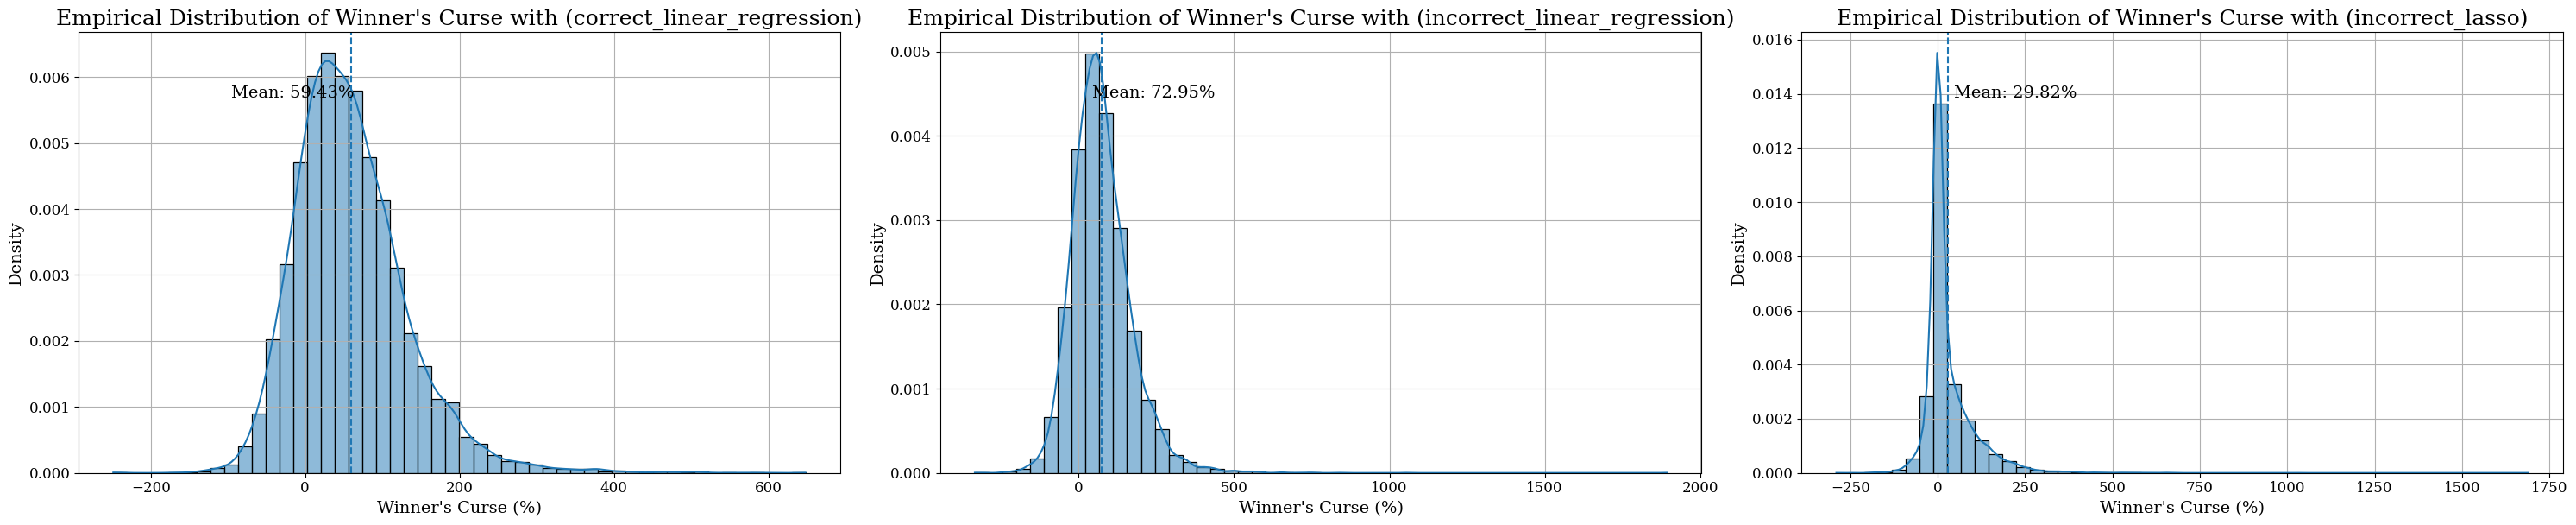

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(30, 6.18))

for idx, (demand_model, result_dict) in enumerate(wc_result_dict.items()):
    avg_wc_pct = result_dict['emp_wc_pct_dstn_arr'].mean()
    se_wc_pct = result_dict['emp_wc_pct_dstn_arr'].std() / np.sqrt(data_params['sample_size'])

    print(f"{demand_model} has mean winner's curse of {avg_wc_pct:.2f} ({se_wc_pct:.2f})%")
    
    sns.histplot(result_dict['emp_wc_pct_dstn_arr'], bins=50, kde=True, stat='density', ax=axes[idx], color='C0')
    axes[idx].axvline(avg_wc_pct, color='C0', linestyle='--')
    axes[idx].annotate(
        f"Mean: {avg_wc_pct:.2f}%", 
        xy=(0.2, 0.85), xycoords='axes fraction', fontsize=axis_label_size
    )
    axes[idx].set_title(f"Empirical Distribution of Winner's Curse with ({demand_model})", fontsize=title_size)

    axes[idx].tick_params(axis='both', which='major', labelsize=tick_label_size)
    axes[idx].set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

# Estimating winner's curse

In [13]:
dgp = ContinuousSegments(**dgp_params)
X, T, Y = dgp.sample(data_params['sample_size'], seed=1)
targ_customers = dgp.sample_individuals(data_params['n_customers'], seed=1)

## Standard bootstrap

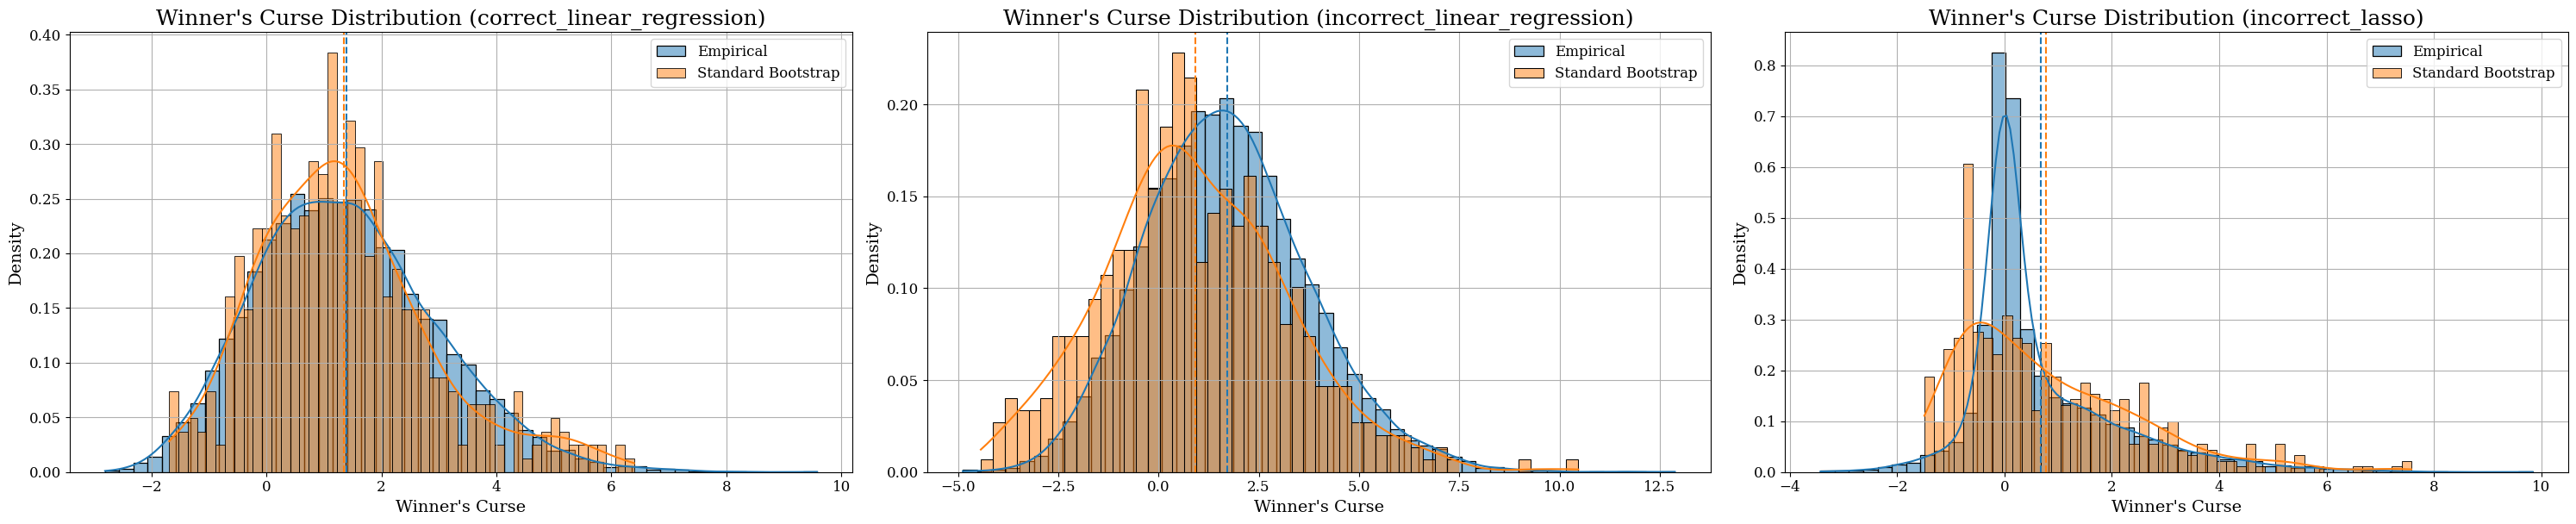

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(30, 6.18))

for idx, demand_model in enumerate(cs.demand_model_dict.keys()):
    boot_wc_dstn_arr = cs.get_wc_boot_dstn(
        X=X, T=T, Y=Y,
        targ_customers=targ_customers, treatment_space=dgp.treatment_space,
        n_bootstraps=500, demand_model=demand_model, 
        n_jobs=-1, verbose=False
    )

    # empirical winner's curse
    sns.histplot(wc_result_dict[demand_model]['emp_wc_dstn_arr'], bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=axes[idx])
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['emp_wc_dstn_arr']), color='C0', linestyle='--')

    # bootstrap winner's curse
    sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C1', label='Standard Bootstrap', ax=axes[idx])
    axes[idx].axvline(np.nanmean(boot_wc_dstn_arr), color='C1', linestyle='--')

    axes[idx].set_title(f'Winner\'s Curse Distribution ({demand_model})', fontsize=title_size)
    axes[idx].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].tick_params(labelsize=tick_label_size)
    axes[idx].legend(fontsize=legend_label_size)

    axes[idx].grid()

plt.tight_layout()
plt.show()

## m-out-of-n bootstrap

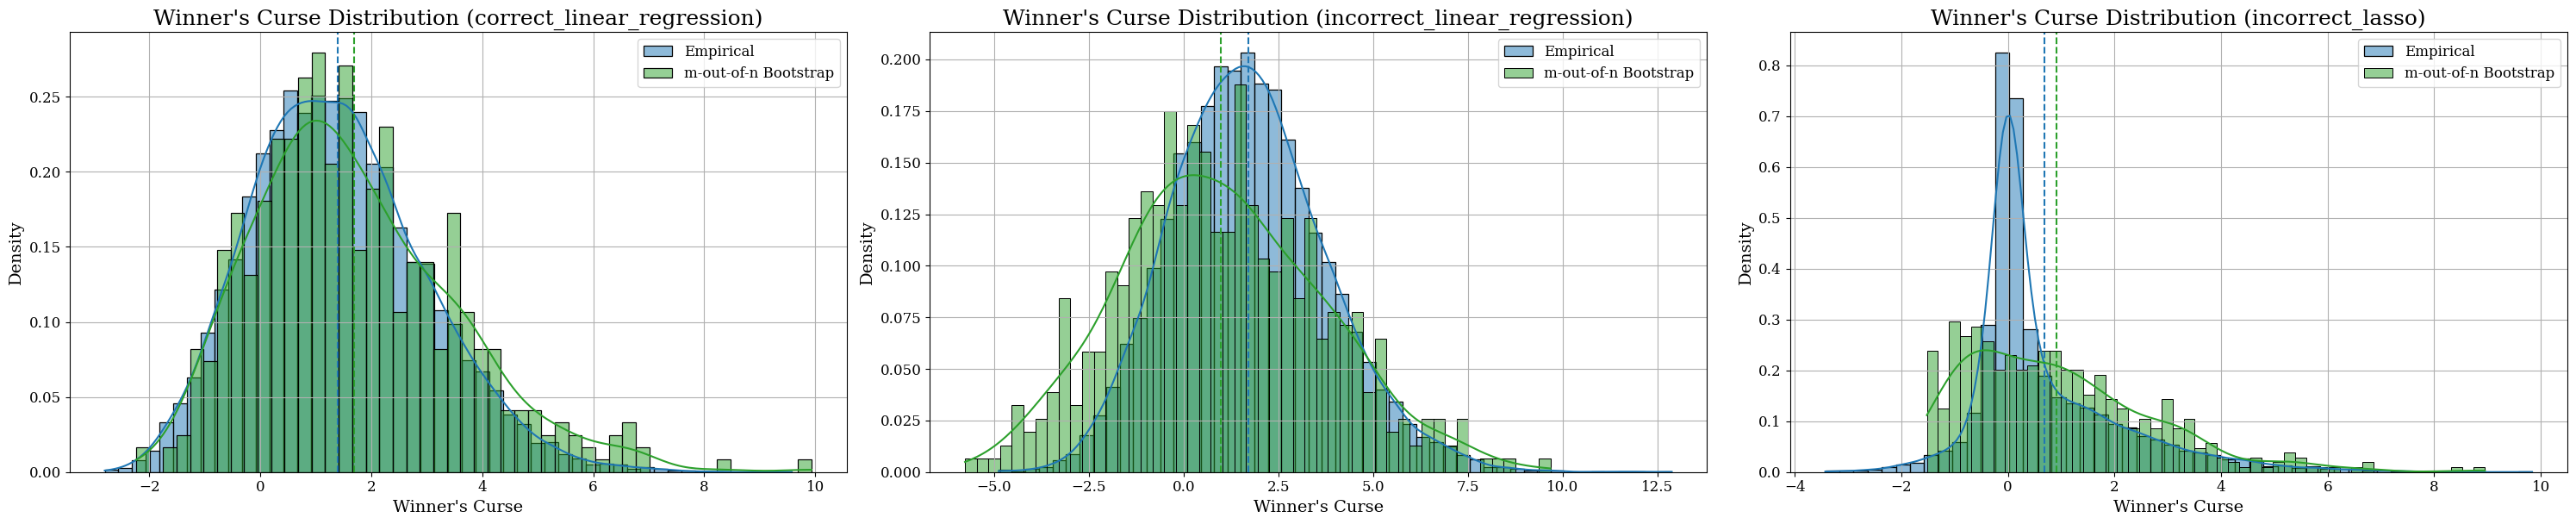

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(30, 6.18))

for idx, demand_model in enumerate(cs.demand_model_dict.keys()):
    mn_boot_wc_dstn_arr = cs.get_wc_m_out_of_n_boot_dstn(
        X=X, T=T, Y=Y,
        targ_customers=targ_customers, treatment_space=dgp.treatment_space,
        n_bootstraps=500, power=0.95, 
        demand_model=demand_model, 
        n_jobs=-1, verbose=False
    )

    # empirical winner's curse
    sns.histplot(wc_result_dict[demand_model]['emp_wc_dstn_arr'], bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=axes[idx])
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['emp_wc_dstn_arr']), color='C0', linestyle='--')

    # bootstrap winner's curse
    sns.histplot(mn_boot_wc_dstn_arr, bins=50, kde=True, stat='density', color='C2', label='m-out-of-n Bootstrap', ax=axes[idx])
    axes[idx].axvline(np.nanmean(mn_boot_wc_dstn_arr), color='C2', linestyle='--')

    axes[idx].set_title(f'Winner\'s Curse Distribution ({demand_model})', fontsize=title_size)
    axes[idx].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].tick_params(labelsize=tick_label_size)
    axes[idx].legend(fontsize=legend_label_size)

    axes[idx].grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [7]:
dgp_params = {
    'treatment_space': np.array([0, 1, 2, 3, 4]),
    'n_features': 2,
    'alpha_lb': 0.5, 'alpha_ub': 1.5,
    'beta_lb': 1, 'beta_ub': 3,
    'noise_std': 10, 'seed': 0
}

data_params = {'sample_size': 100, 'seed': None, 'n_customers': 100}

experiment_params = {
    'n_experiments': 1000, 
    'demand_model': None
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 500, 'n_jobs': 1}
    }, 
    'mn_bootstrap': {
        'estimator': cs.bootstrap_correction_estimate,
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 500, 'power': 0.95, 'n_jobs': 1}
    }, 
    # 'num_bootstrap': {
    #     'estimator': cs.bootstrap_correction_estimate,
    #     'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 500, 'power': -0.45, 'n_jobs': 1}
    # }
}

wc_result_dict = {key: None for key in cs.demand_model_dict.keys()}
for demand_model in cs.demand_model_dict.keys():
    print(f'\nRunning demand model {demand_model}...')
    experiment_params['demand_model'] = demand_model

    result_records = cs.repeated_experiments(
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        n_jobs=-1, verbose=True
    )

    wc_result_dict[demand_model] = {
        'plugin_wc_arr': np.array([record['plugin_wc'] for record in result_records]), 
        'plugin_wc_pct_arr': np.array([record['plugin_wc'] / record['clairvoyant_val'] for record in result_records]), 
        'standard_boot_wc_arr': np.array([record['standard_bootstrap_wc'] for record in result_records]),
        'standard_boot_wc_pct_arr': np.array([record['standard_bootstrap_wc'] / record['clairvoyant_val'] for record in result_records]), 
        'mn_boot_wc_arr': np.array([record['mn_bootstrap_wc'] for record in result_records]),
        'mn_boot_wc_pct_arr': np.array([record['mn_bootstrap_wc'] / record['clairvoyant_val'] for record in result_records]), 
    }


Running demand model correct_linear_regression...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   20.8s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   42.1s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  1.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Running demand model incorrect_linear_regression...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   11.7s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   26.8s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   47.5s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  1.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.



Running demand model incorrect_lasso...
Running 1000 experiments...


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   21.4s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   44.3s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:  1.6min finished


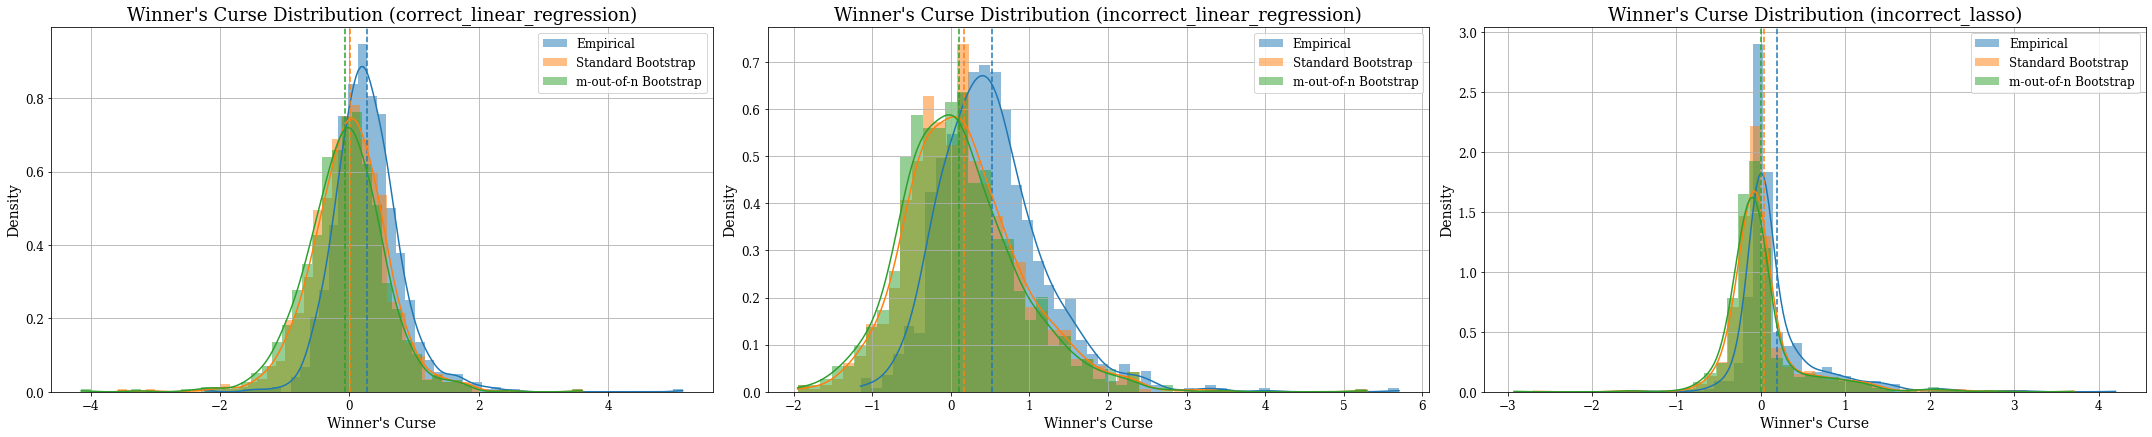

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(30, 6.18))

for idx, demand_model in enumerate(cs.demand_model_dict.keys()):
    # empirical winner's curse
    sns.histplot(wc_result_dict[demand_model]['plugin_wc_pct_arr'], bins=50, kde=True, stat='density', color='C0', label='Empirical', ax=axes[idx], edgecolor=None)
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['plugin_wc_pct_arr']), color='C0', linestyle='--')

    # standard bootstrap
    sns.histplot(wc_result_dict[demand_model]['standard_boot_wc_pct_arr'], bins=50, kde=True, stat='density', color='C1', label='Standard Bootstrap', ax=axes[idx], edgecolor=None)
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['standard_boot_wc_pct_arr']), color='C1', linestyle='--')

    # m-out-of-n bootstrap
    sns.histplot(wc_result_dict[demand_model]['mn_boot_wc_pct_arr'], bins=50, kde=True, stat='density', color='C2', label='m-out-of-n Bootstrap', ax=axes[idx], edgecolor=None)
    axes[idx].axvline(np.nanmean(wc_result_dict[demand_model]['mn_boot_wc_pct_arr']), color='C2', linestyle='--')

    axes[idx].set_title(f'Winner\'s Curse Distribution ({demand_model})', fontsize=title_size)
    axes[idx].set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
    axes[idx].set_ylabel('Density', fontsize=axis_label_size)
    axes[idx].tick_params(labelsize=tick_label_size)
    axes[idx].legend(fontsize=legend_label_size)

    axes[idx].grid()

plt.tight_layout()
plt.show()

In [40]:
mean_df = pd.DataFrame({
    key: {name[:-4]: np.mean(wc_dict[name]) for name in wc_dict.keys()}
    for key, wc_dict in wc_result_dict.items()
})

se_df = pd.DataFrame({
    key: {name[:-4]: np.std(wc_dict[name]) / np.sqrt(data_params['sample_size']) for name in wc_dict.keys()}
    for key, wc_dict in wc_result_dict.items()
})

for demand_model in mean_df.columns:
    print(f'\nDemand model: {demand_model}')
    for key in mean_df.index:
        if key.endswith('pct'):
            print(f"{key} has mean winner's curse of {100 * mean_df.loc[key, demand_model]:.2f} ({100 * se_df.loc[key, demand_model]:.2f})%")


Demand model: correct_linear_regression
plugin_wc_pct has mean winner's curse of 27.62 (5.27)%
standard_boot_wc_pct has mean winner's curse of 0.49 (6.12)%
mn_boot_wc_pct has mean winner's curse of -7.21 (6.35)%

Demand model: incorrect_linear_regression
plugin_wc_pct has mean winner's curse of 52.53 (6.79)%
standard_boot_wc_pct has mean winner's curse of 17.08 (7.51)%
mn_boot_wc_pct has mean winner's curse of 10.15 (7.54)%

Demand model: incorrect_lasso
plugin_wc_pct has mean winner's curse of 19.09 (4.98)%
standard_boot_wc_pct has mean winner's curse of 3.79 (4.83)%
mn_boot_wc_pct has mean winner's curse of 0.49 (4.79)%


# Sensitivity Analysis